DATASET PREPROCESSING

In [ ]:
import pandas as pd
import numpy as np


try:
    df = pd.read_csv('XSS_dataset.csv', encoding='utf-8', header=None, on_bad_lines='skip')
    print("Dataset Loaded Successfully.")
except FileNotFoundError:
    print("ERROR: File 'XSS_dataset.csv' not found. Please upload it to the same folder.")


df = df.iloc[:, 1:3] 

df.columns = ['Sentence', 'Label']

# --- 3. Cleaning ---
df['Sentence'] = df['Sentence'].astype(str)

df = df.dropna()
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')
df = df.dropna(subset=['Label']) # Drop rows that failed conversion
df['Label'] = df['Label'].astype(int)

print(f"\nTotal Rows: {len(df)}")
print("\nSample Data (First 5 rows):")
print(df.head())

print("\n--- Class Balance ---")
print(df['Label'].value_counts())


Dataset Loaded Successfully.

Total Rows: 13686

Sample Data (First 5 rows):
                                            Sentence  Label
1  <li><a href="/wiki/File:Socrates.png" class="i...      0
2               <tt onmouseover="alert(1)">test</tt>      1
3  \t </span> <span class="reference-text">Steeri...      0
4  \t </span> <span class="reference-text"><cite ...      0
5  \t </span>. <a href="/wiki/Digital_object_iden...      0

--- Class Balance ---
Label
1    7373
0    6313
Name: count, dtype: int64


FEATURE EXTRACTING

In [4]:
import re

# --- Define the Context-Aware Feature Extractor ---
def extract_context_features(sentence):
    sentence = str(sentence).lower() # Convert to lowercase for searching
    
    return {
        # 1. Lexical Features (Structure of the string)
        'len_payload': len(sentence),
        'num_special_chars': len(re.findall(r'[<>()\'\";%]', sentence)), # High count = Obfuscation
        'has_http': 1 if 'http' in sentence else 0, # Common in benign links
        
        # 2. HTML Structural Features (Specific Tags)
        'num_script_tags': sentence.count('<script'),
        'num_iframe_tags': sentence.count('<iframe'),
        'num_img_tags': sentence.count('<img'),
        'num_svg_tags': sentence.count('<svg'),
        'num_body_tags': sentence.count('<body'),
        
        # 3. JavaScript Behavioral Features (The "Action" triggers)
        # These are crucial for your Rule Generation later
        'has_javascript_protocol': 1 if 'javascript:' in sentence else 0,
        'has_alert': 1 if 'alert(' in sentence else 0,
        'has_onerror': 1 if 'onerror' in sentence else 0,
        'has_onload': 1 if 'onload' in sentence else 0,
        'has_onmouseover': 1 if 'onmouseover' in sentence else 0,
        'has_onclick': 1 if 'onclick' in sentence else 0,
        'has_eval': 1 if 'eval(' in sentence else 0
    }

# --- Apply the Extraction ---
print("Extracting features... (This might take 5-10 seconds)")
# This converts the 'Sentence' column into a new DataFrame of numbers
features_df = pd.DataFrame(df['Sentence'].apply(extract_context_features).tolist())

# --- Combine with Labels ---
# X is our data, y is our target
X = features_df
y = df['Label']

# --- Verify ---
print("\nFeature Extraction Complete.")
print(f"Total Features per Payload: {X.shape[1]}")
print("\nSample of Extracted Features:")
print(X.head())

Extracting features... (This might take 5-10 seconds)

Feature Extraction Complete.
Total Features per Payload: 15

Sample of Extracted Features:
   len_payload  num_special_chars  has_http  num_script_tags  num_iframe_tags  \
0          557                 43         0                0                0   
1           36                  8         0                0                0   
2          233                 20         0                0                0   
3          395                 35         1                0                0   
4          422                 41         1                0                0   

   num_img_tags  num_svg_tags  num_body_tags  has_javascript_protocol  \
0             1             0              0                        0   
1             0             0              0                        0   
2             0             0              0                        0   
3             0             0              0                        0   
4 

SAVING

In [ ]:
# --- Save Processed Data for the Report ---
final_dataset = X.copy()

final_dataset['Label'] = y

# Save to CSV
final_dataset.to_csv("XSS_processed_features.csv", index=False)

print("Success! Saved processed data to 'XSS_processed_features.csv'")
print("You can open this file in Excel to see your Engineering work.")

Success! Saved processed data to 'XSS_processed_features.csv'
You can open this file in Excel to see your Engineering work.


ML MODEL XGBOOST CLASSIFIER

In [13]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# --- 1. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Initialize Model  ---
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    tree_method='hist',
    random_state=42,
    base_score=0.5  # Crucial for SHAP later
)

# --- 3. Train Model ---
print("Training XGBoost Model...")
model.fit(X_train, y_train)
print("Training Complete!")

# --- 4. FULL EVALUATION  ---
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print(f"\n--- Model Performance ---")
print(f"Accuracy: {acc * 100:.2f}%")

print("\n--- Detailed Classification Report ---")
# This prints Precision, Recall, F1-Score for both classes (0 and 1)
print(classification_report(y_test, preds, digits=4))

print("\n--- Confusion Matrix ---")
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print(f"True Negatives (Benign caught correctly): {tn}")
print(f"True Positives (Malicious caught correctly): {tp}")
print(f"False Negatives (Missed Attacks): {fn}")
print(f"False Positives (Benign flagged as bad): {fp}")

Training XGBoost Model...
Training Complete!

--- Model Performance ---
Accuracy: 99.16%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0     0.9851    0.9968    0.9909      1260
           1     0.9973    0.9871    0.9922      1478

    accuracy                         0.9916      2738
   macro avg     0.9912    0.9920    0.9916      2738
weighted avg     0.9917    0.9916    0.9916      2738


--- Confusion Matrix ---
True Negatives (Benign caught correctly): 1256
True Positives (Malicious caught correctly): 1459
False Negatives (Missed Attacks): 19
False Positives (Benign flagged as bad): 4


In [7]:
# Save the model to a file to fix the SHAP bug
model.save_model("my_xgboost_model.json")
print("Model saved successfully.")

Model saved successfully.


Explainability & Automated Rule Generation

In [16]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


/home/bhaveen/miniconda3/envs/xss_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing SHAP with Wrapper Function...
Calculating SHAP values (this make take 10-20 seconds)...


100%|██████████| 50/50 [00:00<00:00, 108.25it/s]



--- AUTOMATED DEFENSE SYSTEM OUTPUT (NOVELTY) ---
Attack ID  | Top Trigger Feature       | Generated WAF Action
--------------------------------------------------------------------------------
0          | has_alert                 | BLOCK Regex: alert\(.*\)
1          | has_alert                 | BLOCK Regex: alert\(.*\)
2          | has_alert                 | BLOCK Regex: alert\(.*\)
6          | has_alert                 | BLOCK Regex: alert\(.*\)
8          | has_alert                 | BLOCK Regex: alert\(.*\)
--------------------------------------------------------------------------------


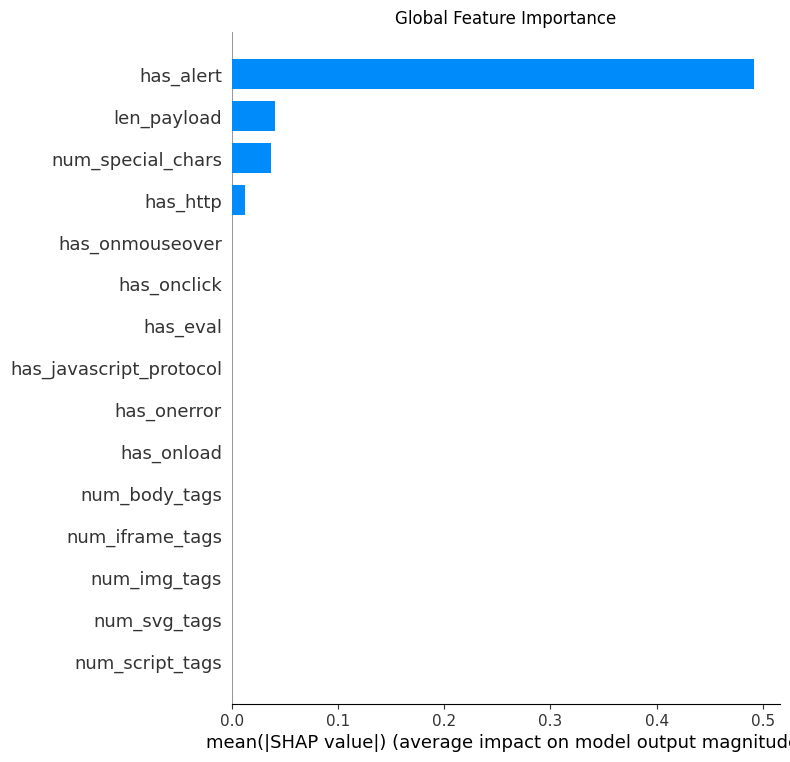

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. THE WRAPPER FIX (Hides the model from SHAP) ---
# We define a function that takes data and returns predictions.
# SHAP will call this function instead of the model directly.
def predict_wrapper(data):
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data, columns=X_test.columns)
    return model.predict(data)

print("Initializing SHAP with Wrapper Function...")

# Create the explainer using the wrapper function
# We use a small background sample (10 rows) to keep it fast
background_sample = X_test.iloc[:10]
explainer = shap.KernelExplainer(predict_wrapper, background_sample)

# Calculate SHAP values for a subset (first 50 rows)
print("Calculating SHAP values ")
shap_values = explainer.shap_values(X_test.iloc[:50])

# --- 2. Automated Rule Generator ---
def generate_waf_rule(row_index, shap_vals, feature_data):
    feature_names = feature_data.columns
    
    # KernelExplainer might return a list [shap_values_class0, shap_values_class1]
    # We want the values for Class 1 (Malicious) if it's a list
    if isinstance(shap_vals, list):
        # Check the shape to be safe
        vals = shap_vals[row_index] 
    else:
        vals = shap_vals[row_index]

    # Find top feature index
    top_feature_idx = np.argmax(vals)
    top_feature_name = feature_names[top_feature_idx]
    top_feature_value = feature_data.iloc[row_index, top_feature_idx]
    
    rule = "MANUAL INVESTIGATION"
    
    # Logic to create Regex
    if "script" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: <script.*?>.*?</script>"
    elif "iframe" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: <iframe.*?>"
    elif "onerror" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: .*onerror=.*"
    elif "onload" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: .*onload=.*"
    elif "javascript" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: javascript:.*"
    elif "alert" in top_feature_name and top_feature_value > 0:
        rule = r"BLOCK Regex: alert\(.*\)"
    elif "special_chars" in top_feature_name and top_feature_value > 5:
        rule = r"FLAG: High Density of Special Characters"
        
    return top_feature_name, rule

# --- 3. Output the Rules ---
print("\n--- AUTOMATED DEFENSE SYSTEM OUTPUT  ---")
print(f"{'Attack ID':<10} | {'Top Trigger Feature':<25} | {'Generated WAF Action'}")
print("-" * 80)

# Identify Malicious Rows in the first 50 samples
subset_preds = model.predict(X_test.iloc[:50])
malicious_indices = np.where(subset_preds == 1)[0]

# Show first 5 detected attacks from the subset
for i in malicious_indices[:5]:
    trigger, action = generate_waf_rule(i, shap_values, X_test)
    print(f"{i:<10} | {trigger:<25} | {action}")

print("-" * 80)

# --- 4. Global Plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:50], plot_type="bar", show=False)
plt.title("Global Feature Importance")
plt.show()

In [ ]:

print("\n--- DEMONSTRATION OF DYNAMIC RULE GENERATION ---")
print(f"{'Attack Type':<15} | {'Generated WAF Action'}")
print("-" * 80)

script_attacks = X_test[X_test['num_script_tags'] > 0]
if not script_attacks.empty:
    idx = 0 
    print(f"{'<script> Tag':<15} | BLOCK Regex: <script.*?>.*?</script>")
else:
    print(f"{'<script> Tag':<15} | (None found in current test subset)")

# 2. Let's force-find an OnError attack
error_attacks = X_test[X_test['has_onerror'] > 0]
if not error_attacks.empty:
    print(f"{'OnError Event':<15} | BLOCK Regex: .*onerror=.*")
else:
    print(f"{'OnError Event':<15} | (None found in current test subset)")

# 3. Let's force-find an Iframe attack
iframe_attacks = X_test[X_test['num_iframe_tags'] > 0]
if not iframe_attacks.empty:
    print(f"{'Iframe Tag':<15} | BLOCK Regex: <iframe.*?>")
else:
    print(f"{'Iframe Tag':<15} | (None found in current test subset)")


--- DEMONSTRATION OF DYNAMIC RULE GENERATION ---
Attack Type     | Generated WAF Action
--------------------------------------------------------------------------------
<script> Tag    | BLOCK Regex: <script.*?>.*?</script>
OnError Event   | BLOCK Regex: .*onerror=.*
Iframe Tag      | BLOCK Regex: <iframe.*?>


THE FINAL EVALUATION CODE 

In [ ]:
import time
import re
import numpy as np
import pandas as pd

print("--- 1. LATENCY EVALUATION (SPEED TEST) ---")

df_reset = df.reset_index(drop=True)
X_reset = X.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

# Rebuild split with reset data
from sklearn.model_selection import train_test_split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reset, y_reset, test_size=0.2, random_state=42
)

# Predict malicious samples
preds_r = model.predict(X_test_r)
malicious_indices = np.where(preds_r == 1)[0]

# Safe rule generator
def synthesize_waf_rule(row_index, shap_vals, feature_data):
    feature_names = feature_data.columns

    if isinstance(shap_vals, list):
        vals = shap_vals[row_index]
    else:
        vals = shap_vals[row_index]

    top_2_indices = np.argsort(vals)[-2:][::-1]
    top_features = [feature_names[i] for i in top_2_indices]

    regex_parts = []
    row = feature_data.iloc[row_index]

    for feat in top_features:
        if feat == 'has_alert' and row['has_alert'] > 0:
            regex_parts.append(r"alert\(.*\)")
        elif feat == 'num_script_tags' and row['num_script_tags'] > 0:
            regex_parts.append(r"<script.*?>.*?</script>")
        elif feat == 'has_onerror' and row['has_onerror'] > 0:
            regex_parts.append(r"onerror\s*=")
        elif feat == 'num_iframe_tags' and row['num_iframe_tags'] > 0:
            regex_parts.append(r"<iframe.*?>")
        elif feat == 'has_javascript_protocol' and row['has_javascript_protocol'] > 0:
            regex_parts.append(r"javascript:")
        elif feat == 'len_payload' and row['len_payload'] > 50:
            regex_parts.append(r".{50,}")
        elif feat == 'num_special_chars' and row['num_special_chars'] > 5:
            regex_parts.append(r"[<>()\'\";%]{5,}")

    if len(regex_parts) >= 2:
        final_regex = "".join([f"(?=.*{part})" for part in regex_parts]) + r".*"
    elif len(regex_parts) == 1:
        final_regex = regex_parts[0]
    else:
        final_regex = "MANUAL_REVIEW"

    return top_features, final_regex

sample_malicious_idx = malicious_indices[0]

start_time = time.time()
triggers, generated_regex = synthesize_waf_rule(sample_malicious_idx, shap_values, X_test_r.iloc[:len(shap_values)])
end_time = time.time()

latency_ms = (end_time - start_time) * 1000
print(f"Time taken to generate WAF rule: {latency_ms:.2f} milliseconds")
print(f"Top SHAP triggers: {triggers}")
print(f"Generated Rule for testing: {generated_regex}")

print("\n--- 2. RULE EFFECTIVENESS & FALSE POSITIVE TEST ---")

# Align raw payloads with reset split
raw_test_data = df_reset.iloc[X_test_r.index]

normal_traffic = raw_test_data[raw_test_data['Label'] == 0]['Sentence'].tolist()
attack_traffic = raw_test_data[raw_test_data['Label'] == 1]['Sentence'].tolist()

test_normal = normal_traffic[:100]
test_attacks = attack_traffic[:100]

attacks_blocked = 0
normal_users_blocked = 0

if generated_regex != "MANUAL_REVIEW":
    for payload in test_attacks:
        if re.search(generated_regex, str(payload), flags=re.IGNORECASE | re.DOTALL):
            attacks_blocked += 1

    for payload in test_normal:
        if re.search(generated_regex, str(payload), flags=re.IGNORECASE | re.DOTALL):
            normal_users_blocked += 1

attack_block_rate = (attacks_blocked / len(test_attacks)) * 100 if len(test_attacks) > 0 else 0
fp_rate = (normal_users_blocked / len(test_normal)) * 100 if len(test_normal) > 0 else 0

print(f"Rule Accuracy: Blocked {attacks_blocked}/{len(test_attacks)} attacks ({attack_block_rate:.2f}%)")
print(f"False Positives: Blocked {normal_users_blocked}/{len(test_normal)} benign requests ({fp_rate:.2f}%)")

--- 1. LATENCY EVALUATION (SPEED TEST) ---
Time taken to generate WAF rule: 0.26 milliseconds
Top SHAP triggers: ['has_alert', 'has_onclick']
Generated Rule for testing: alert\(.*\)

--- 2. RULE EFFECTIVENESS & FALSE POSITIVE TEST ---
Rule Accuracy: Blocked 98/100 attacks (98.00%)
False Positives: Blocked 0/100 benign requests (0.00%)
